<h1 align="center">🏦 Loan Default Prediction Project</h1>

<h3 align="center">
Machine Learning Classification for Financial Institutions
</h3>

<div align="center">
    <img src="loanprediction.jfif" width="600">
</div>

##  Business Objective

A financial institution wants to identify customers who are less likely to default on loans.  
The objective of this project is to build a machine learning model that can predict whether a customer is a good loan applicant or a risky customer.

The project includes:
- Exploratory Data Analysis
- Data Cleaning
- Missing Value Handling
- Feature Engineering
- Classification Modeling
- Model Evaluation
- Business Recommendations

<h1 align="center">📖 Data Dictionary</h1>

<br>

| Feature | Description |
|---|---|
| Loan ID | A unique identifier for the loan information |
| Customer ID | A unique identifier for the customer. Customers may have more than one loan |
| Loan Status | Indicates whether the loan was paid back or defaulted |
| Current Loan Amount | Loan amount that was paid off or defaulted |
| Term | Indicates whether the loan is short term or long term |
| Credit Score | Credit score between 0 and 800 |
| Years in current job | Number of years the customer has been in current job |
| Home Ownership | Home ownership status (Rent, Home Mortgage, Own) |
| Annual Income | Customer annual income |
| Purpose | Purpose of the loan |
| Monthly Debt | Monthly debt payment |
| Years of Credit History | Years since first credit history entry |
| Months since last delinquent | Months since last delinquent payment |
| Number of Open Accounts | Total open credit accounts |
| Number of Credit Problems | Number of credit problems |
| Current Credit Balance | Current total debt |
| Maximum Open Credit | Maximum available credit |
| Bankruptcies | Number of bankruptcies |
| Tax Liens | Number of tax liens |

In [3]:
##Import Libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

In [4]:
df = pd.read_csv("LoansTrainingSet.csv")

In [5]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [6]:
df.tail()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
256979,fffef5b7-be99-4666-ac70-2a397d2ee435,7211a8e3-cba4-4132-b939-222eed8a662c,Fully Paid,3911,Short Term,NaN,2 years,Rent,NaN,Debt Consolidation,"$1,706.58",19.9,NaN,16,0,43992,44080,0.0,0.0
256980,ffffca93-aa8c-4123-b8ff-7852f6df889a,616fef0c-8f09-4327-9b5c-48fcfaa52934,Fully Paid,5078,Short Term,737.0,10+ years,Own Home,77186.0,Debt Consolidation,"$1,376.47",19.1,47.0,9,0,1717,9758,0.0,0.0
256981,ffffcb2e-e48e-4d2c-a0d6-ed6bce5bfdbe,971a6682-183b-4a52-8bce-1d3429ade295,Charged Off,12116,Short Term,7460.0,9 years,Home Mortgage,52504.0,Debt Consolidation,$297.96,15.1,82.0,8,0,3315,20090,0.0,0.0
256982,ffffcb2e-e48e-4d2c-a0d6-ed6bce5bfdbe,971a6682-183b-4a52-8bce-1d3429ade295,Charged Off,12116,Short Term,746.0,9 years,Home Mortgage,52504.0,Debt Consolidation,$297.96,15.1,82.0,8,0,3315,20090,0.0,0.0
256983,ffffe32e-ed17-459f-9cfd-7b9ee7972933,97281336-1e45-41d2-acb2-263ce56a590e,Fully Paid,27902,Long Term,678.0,10+ years,Home Mortgage,117480.0,Debt Consolidation,"$2,525.82",18.0,11.0,10,0,28317,62371,0.0,0.0


In [7]:
df.shape

(256984, 19)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  195308 non-null  float64
 6   Years in current job          245508 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 195308 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Months since last delinquent  116601 non-nul

In [9]:
# Duplicate rows count
df.duplicated().sum()

np.int64(16610)

In [10]:
# Remove duplicates
df = df.drop_duplicates()

In [11]:
df.shape

(240374, 19)

In [12]:
df["Credit Score"].describe()

count    181028.000000
mean       1236.274079
std        1737.765627
min         585.000000
25%         715.000000
50%         734.000000
75%         744.000000
max        7510.000000
Name: Credit Score, dtype: float64

In [13]:
df["Monthly Debt"].head()

0       $584.03
1    $1,106.04 
2    $1,321.85 
3       $751.92
4       $355.18
Name: Monthly Debt, dtype: object

In [14]:
df["Monthly Debt"] = (df["Monthly Debt"].replace('[\$,]', '', regex=True).astype(float))

In [15]:
df["Monthly Debt"].head()

0     584.03
1    1106.04
2    1321.85
3     751.92
4     355.18
Name: Monthly Debt, dtype: float64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       240374 non-null  object 
 1   Customer ID                   240374 non-null  object 
 2   Loan Status                   240374 non-null  object 
 3   Current Loan Amount           240374 non-null  int64  
 4   Term                          240374 non-null  object 
 5   Credit Score                  181028 non-null  float64
 6   Years in current job          229930 non-null  object 
 7   Home Ownership                240374 non-null  object 
 8   Annual Income                 181028 non-null  float64
 9   Purpose                       240374 non-null  object 
 10  Monthly Debt                  240374 non-null  float64
 11  Years of Credit History       240374 non-null  float64
 12  Months since last delinquent  108947 non-null  fl

In [17]:
df["Maximum Open Credit"].head(20)

0      16056
1      19149
2      28335
3      43915
4      37081
5       4671
6      16954
7      16954
8      16579
9      15676
10     22711
11     41726
12     22800
13     22775
15     22800
16     17262
17     15982
18     20743
20    101110
21    101110
Name: Maximum Open Credit, dtype: object

In [18]:
df["Maximum Open Credit"].apply(type).value_counts()

Maximum Open Credit
<class 'int'>    209694
<class 'str'>     30680
Name: count, dtype: int64

In [19]:
df["Maximum Open Credit"] = pd.to_numeric(df["Maximum Open Credit"],errors="coerce")

In [20]:
df["Maximum Open Credit"].dtype

dtype('float64')

In [21]:
df["Maximum Open Credit"].isnull().sum()

np.int64(4)

In [22]:
df["Maximum Open Credit"].fillna(df["Maximum Open Credit"].median(),inplace=True)

In [23]:
df["Maximum Open Credit"].isnull().sum()

np.int64(0)

In [24]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     59346
Years in current job             10444
Home Ownership                       0
Annual Income                    59346
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    131427
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       492
Tax Liens                           23
dtype: int64

In [25]:
df["Annual Income"].fillna(df["Annual Income"].median(),inplace=True)

In [26]:
df["Years in current job"].fillna(
    df["Years in current job"].mode()[0],inplace=True)

In [27]:
df["Months since last delinquent"].fillna(0,inplace=True)

In [28]:
df["Bankruptcies"].fillna(df["Bankruptcies"].median(),inplace=True)

In [29]:
df["Tax Liens"].fillna(df["Tax Liens"].median(),inplace=True)

In [30]:
df.isnull().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    59346
Years in current job                0
Home Ownership                      0
Annual Income                       0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent        0
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                        0
Tax Liens                           0
dtype: int64

In [31]:
df.select_dtypes(include="object").columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Term', 'Years in current job',
       'Home Ownership', 'Purpose'],
      dtype='object')

In [32]:
df.drop(["Loan ID", "Customer ID"],axis=1,inplace=True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 17 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan Status                   240374 non-null  object 
 1   Current Loan Amount           240374 non-null  int64  
 2   Term                          240374 non-null  object 
 3   Credit Score                  181028 non-null  float64
 4   Years in current job          240374 non-null  object 
 5   Home Ownership                240374 non-null  object 
 6   Annual Income                 240374 non-null  float64
 7   Purpose                       240374 non-null  object 
 8   Monthly Debt                  240374 non-null  float64
 9   Years of Credit History       240374 non-null  float64
 10  Months since last delinquent  240374 non-null  float64
 11  Number of Open Accounts       240374 non-null  int64  
 12  Number of Credit Problems     240374 non-null  in

In [34]:
df["Loan Status"].value_counts()

Loan Status
Fully Paid     176191
Charged Off     64183
Name: count, dtype: int64

In [35]:
df["Loan Status"] = df["Loan Status"].map({"Fully Paid": 1,"Charged Off": 0})

In [36]:
df["Loan Status"].head()

0    1
1    1
2    1
3    1
4    1
Name: Loan Status, dtype: int64

In [37]:
# Önce boşlukları temizle
df["Loan Status"] = df["Loan Status"].astype(str).str.strip()

In [38]:
df["Loan Status"] = df["Loan Status"].map({"Fully Paid": 1,"Charged Off": 0})

In [39]:
df["Loan Status"].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Loan Status, dtype: float64

In [40]:
df["Loan Status"].value_counts()

Series([], Name: count, dtype: int64)

In [41]:
df["Loan Status"].unique()

array([nan])

In [42]:
df = pd.read_csv("LoansTrainingSet.csv")

In [43]:
# Duplicate sil
df = df.drop_duplicates()

In [44]:
# Monthly Debt temizleme
df["Monthly Debt"] = (df["Monthly Debt"].replace('[\$,]', '', regex=True).astype(float))

In [45]:
# Maximum Open Credit numeric yap
df["Maximum Open Credit"] = pd.to_numeric(df["Maximum Open Credit"],errors="coerce")
df["Maximum Open Credit"].fillna(df["Maximum Open Credit"].median(),inplace=True)

In [46]:
# Missing values
df["Annual Income"].fillna(df["Annual Income"].median(), inplace=True)
df["Years in current job"].fillna(df["Years in current job"].mode()[0],inplace=True)
df["Months since last delinquent"].fillna(0, inplace=True)
df["Bankruptcies"].fillna(df["Bankruptcies"].median(),inplace=True)
df["Tax Liens"].fillna(df["Tax Liens"].median(),inplace=True)

In [47]:
# ID kolonlarını sil
df.drop(["Loan ID", "Customer ID"],axis=1,inplace=True)

In [48]:
df["Loan Status"].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [49]:
df["Loan Status"] = df["Loan Status"].replace({"Fully Paid": 1,"Charged Off": 0})

In [50]:
df["Loan Status"].head(30)

0     1
1     1
2     1
3     1
4     1
5     1
6     0
7     0
8     1
9     1
10    1
11    1
12    0
13    0
15    0
16    1
17    1
18    0
20    0
21    0
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    0
Name: Loan Status, dtype: int64

In [51]:
df["Loan Status"].value_counts()

Loan Status
1    176191
0     64183
Name: count, dtype: int64

In [52]:
df["Term"].value_counts()

Term
Short Term    182177
Long Term      58197
Name: count, dtype: int64

In [53]:
df["Term"] = df["Term"].replace({"Short Term": 0,"Long Term": 1})

In [54]:
df["Term"].head(15)


0     0
1     0
2     0
3     0
4     0
5     0
6     1
7     1
8     0
9     0
10    0
11    0
12    0
13    0
15    0
Name: Term, dtype: int64

In [55]:
df["Years in current job"].unique()

array(['10+ years', '4 years', '6 years', '5 years', '3 years', '2 years',
       '< 1 year', '1 year', '7 years', '9 years', '8 years'],
      dtype=object)

In [56]:
df["Years in current job"] = (df["Years in current job"]
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.replace("< 1", "0", regex=False))

In [57]:
df["Years in current job"] = pd.to_numeric(df["Years in current job"])

In [58]:
df["Years in current job"].head()

0    10
1     4
2    10
3    10
4     4
Name: Years in current job, dtype: int64

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 17 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan Status                   240374 non-null  int64  
 1   Current Loan Amount           240374 non-null  int64  
 2   Term                          240374 non-null  int64  
 3   Credit Score                  181028 non-null  float64
 4   Years in current job          240374 non-null  int64  
 5   Home Ownership                240374 non-null  object 
 6   Annual Income                 240374 non-null  float64
 7   Purpose                       240374 non-null  object 
 8   Monthly Debt                  240374 non-null  float64
 9   Years of Credit History       240374 non-null  float64
 10  Months since last delinquent  240374 non-null  float64
 11  Number of Open Accounts       240374 non-null  int64  
 12  Number of Credit Problems     240374 non-null  in

In [60]:
df["Credit Score"].fillna(df["Credit Score"].median(),inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 17 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan Status                   240374 non-null  int64  
 1   Current Loan Amount           240374 non-null  int64  
 2   Term                          240374 non-null  int64  
 3   Credit Score                  240374 non-null  float64
 4   Years in current job          240374 non-null  int64  
 5   Home Ownership                240374 non-null  object 
 6   Annual Income                 240374 non-null  float64
 7   Purpose                       240374 non-null  object 
 8   Monthly Debt                  240374 non-null  float64
 9   Years of Credit History       240374 non-null  float64
 10  Months since last delinquent  240374 non-null  float64
 11  Number of Open Accounts       240374 non-null  int64  
 12  Number of Credit Problems     240374 non-null  in

In [62]:
df["Home Ownership"].value_counts()

Home Ownership
Home Mortgage    117231
Rent             101209
Own Home          21389
HaveMortgage        545
Name: count, dtype: int64

In [63]:
df["Purpose"].value_counts()

Purpose
Debt Consolidation      190656
Home Improvements        14106
other                    13221
Other                     9115
Business Loan             4275
Buy a Car                 3150
Medical Bills             2687
Take a Trip               1467
Buy House                 1445
Educational Expenses       252
Name: count, dtype: int64

In [64]:
df["Purpose"] = df["Purpose"].replace({"other": "Other"})

In [65]:
purpose_dummies = pd.get_dummies(df["Purpose"],prefix="Purpose")

In [66]:
df = pd.concat([df, purpose_dummies], axis=1)

In [67]:
df.drop("Purpose",axis=1,inplace=True)

In [68]:
df.head()

,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,...,Tax Liens,Purpose_Business Loan,Purpose_Buy House,Purpose_Buy a Car,Purpose_Debt Consolidation,Purpose_Educational Expenses,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip
0,1,11520,0,741.0,10,Home Mortgage,33694.0,584.03,12.3,41.0,...,0.0,False,False,False,True,False,False,False,False,False
1,1,3441,0,734.0,4,Home Mortgage,42269.0,1106.04,26.3,0.0,...,0.0,False,False,False,False,False,False,False,True,False
2,1,21029,0,747.0,10,Home Mortgage,90126.0,1321.85,28.8,0.0,...,0.0,False,False,False,True,False,False,False,False,False
3,1,18743,0,747.0,10,Own Home,38072.0,751.92,26.2,0.0,...,0.0,False,False,False,True,False,False,False,False,False
4,1,11731,0,746.0,4,Rent,50025.0,355.18,11.5,0.0,...,0.0,False,False,False,True,False,False,False,False,False


In [69]:
df["Home Ownership"].value_counts()

Home Ownership
Home Mortgage    117231
Rent             101209
Own Home          21389
HaveMortgage        545
Name: count, dtype: int64

In [70]:
home_dummies = pd.get_dummies(df["Home Ownership"], prefix="Home")
df = pd.concat([df, home_dummies], axis=1)
df.drop("Home Ownership", axis=1, inplace=True)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240374 entries, 0 to 256983
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan Status                   240374 non-null  int64  
 1   Current Loan Amount           240374 non-null  int64  
 2   Term                          240374 non-null  int64  
 3   Credit Score                  240374 non-null  float64
 4   Years in current job          240374 non-null  int64  
 5   Annual Income                 240374 non-null  float64
 6   Monthly Debt                  240374 non-null  float64
 7   Years of Credit History       240374 non-null  float64
 8   Months since last delinquent  240374 non-null  float64
 9   Number of Open Accounts       240374 non-null  int64  
 10  Number of Credit Problems     240374 non-null  int64  
 11  Current Credit Balance        240374 non-null  int64  
 12  Maximum Open Credit           240374 non-null  fl

### Feature Engineering

$$
Credit\ Utilization = \frac{Current\ Credit\ Balance}{Maximum\ Open\ Credit}
$$

In [72]:
df["Credit Utilization"] = (df["Current Credit Balance"] / df["Maximum Open Credit"])

$$
Debt\ to\ Income\ Ratio = \frac{Monthly\ Debt}{Annual\ Income}
$$

In [73]:
df["Debt to Income Ratio"] = (df["Monthly Debt"] /df["Annual Income"])

In [74]:
df.head(30)

,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,...,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Home_HaveMortgage,Home_Home Mortgage,Home_Own Home,Home_Rent,Credit Utilization,Debt to Income Ratio
0,1,11520,0,741.0,10,33694.0,584.03,12.3,41.0,10,...,False,False,False,False,False,True,False,False,0.421026,0.017333
1,1,3441,0,734.0,4,42269.0,1106.04,26.3,0.0,17,...,False,False,True,False,False,True,False,False,0.327014,0.026167
2,1,21029,0,747.0,10,90126.0,1321.85,28.8,0.0,5,...,False,False,False,False,False,True,False,False,0.739968,0.014667
3,1,18743,0,747.0,10,38072.0,751.92,26.2,0.0,9,...,False,False,False,False,False,False,True,False,0.513014,0.019750
4,1,11731,0,746.0,4,50025.0,355.18,11.5,0.0,12,...,False,False,False,False,False,False,False,True,0.469000,0.007100
5,1,10208,0,716.0,10,41853.0,561.52,13.2,0.0,4,...,False,False,False,False,False,False,False,True,0.490045,0.013416
6,0,24613,1,6640.0,6,49225.0,542.29,17.6,73.0,7,...,False,False,False,False,False,False,False,True,0.833019,0.011017
7,0,24613,1,734.0,6,61505.0,542.29,17.6,73.0,7,...,False,False,False,False,False,False,False,True,0.833019,0.008817
8,1,10036,0,734.0,5,61505.0,386.36,17.7,0.0,7,...,False,False,False,False,False,False,False,True,0.721998,0.006282
9,1,2036,0,733.0,10,55985.0,741.79,19.8,29.0,7,...,False,False,False,False,False,True,False,False,0.696989,0.013250


In [99]:
df.tail(30)

,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,...,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Home_HaveMortgage,Home_Home Mortgage,Home_Own Home,Home_Rent,Credit Utilization,Debt to Income Ratio
256951,1,8611,0,751.0,10,74159.0,760.13,28.6,72.0,17,...,True,False,False,False,False,True,False,False,0.130991,0.010250
256952,0,12262,1,7410.0,10,40872.0,705.04,16.5,0.0,11,...,False,False,False,False,False,True,False,False,0.609967,0.017250
256953,1,99999999,0,698.0,7,65941.0,1364.97,21.5,0.0,16,...,False,False,False,False,False,False,False,True,0.811004,0.020700
256954,1,99999999,0,742.0,10,118128.0,2608.66,17.0,0.0,17,...,False,False,False,False,False,False,False,True,0.632006,0.022083
256955,1,11057,0,727.0,1,63328.0,1155.73,7.0,0.0,14,...,False,False,False,False,False,False,False,True,0.773927,0.018250
256956,1,5366,0,737.0,4,44924.0,345.54,17.0,46.0,12,...,False,False,False,False,False,False,False,True,0.710075,0.007692
256957,1,9833,0,743.0,6,83581.0,1643.75,32.8,56.0,10,...,False,False,False,False,False,True,False,False,0.800014,0.019667
256958,1,10414,0,742.0,9,30186.0,286.77,9.9,22.0,8,...,False,False,False,False,False,False,True,False,0.292975,0.009500
256959,1,9753,0,734.0,2,61505.0,469.35,23.2,80.0,7,...,False,False,False,False,False,False,True,False,0.543036,0.007631
256960,1,15903,1,687.0,2,161296.0,430.13,27.0,47.0,9,...,False,True,False,False,False,False,False,True,0.288009,0.002667


In [75]:
df["Credit Score"] = df["Credit Score"].apply(lambda x: x / 10 if x > 850 else x)

In [76]:
df.tail(30)

,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,...,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Home_HaveMortgage,Home_Home Mortgage,Home_Own Home,Home_Rent,Credit Utilization,Debt to Income Ratio
256951,1,8611,0,751.0,10,74159.0,760.13,28.6,72.0,17,...,True,False,False,False,False,True,False,False,0.130991,0.010250
256952,0,12262,1,741.0,10,40872.0,705.04,16.5,0.0,11,...,False,False,False,False,False,True,False,False,0.609967,0.017250
256953,1,99999999,0,698.0,7,65941.0,1364.97,21.5,0.0,16,...,False,False,False,False,False,False,False,True,0.811004,0.020700
256954,1,99999999,0,742.0,10,118128.0,2608.66,17.0,0.0,17,...,False,False,False,False,False,False,False,True,0.632006,0.022083
256955,1,11057,0,727.0,1,63328.0,1155.73,7.0,0.0,14,...,False,False,False,False,False,False,False,True,0.773927,0.018250
256956,1,5366,0,737.0,4,44924.0,345.54,17.0,46.0,12,...,False,False,False,False,False,False,False,True,0.710075,0.007692
256957,1,9833,0,743.0,6,83581.0,1643.75,32.8,56.0,10,...,False,False,False,False,False,True,False,False,0.800014,0.019667
256958,1,10414,0,742.0,9,30186.0,286.77,9.9,22.0,8,...,False,False,False,False,False,False,True,False,0.292975,0.009500
256959,1,9753,0,734.0,2,61505.0,469.35,23.2,80.0,7,...,False,False,False,False,False,False,True,False,0.543036,0.007631
256960,1,15903,1,687.0,2,161296.0,430.13,27.0,47.0,9,...,False,True,False,False,False,False,False,True,0.288009,0.002667


In [102]:
df.head(30)

,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,...,Purpose_Home Improvements,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Home_HaveMortgage,Home_Home Mortgage,Home_Own Home,Home_Rent,Credit Utilization,Debt to Income Ratio
0,1,11520,0,741.0,10,33694.0,584.03,12.3,41.0,10,...,False,False,False,False,False,True,False,False,0.421026,0.017333
1,1,3441,0,734.0,4,42269.0,1106.04,26.3,0.0,17,...,False,False,True,False,False,True,False,False,0.327014,0.026167
2,1,21029,0,747.0,10,90126.0,1321.85,28.8,0.0,5,...,False,False,False,False,False,True,False,False,0.739968,0.014667
3,1,18743,0,747.0,10,38072.0,751.92,26.2,0.0,9,...,False,False,False,False,False,False,True,False,0.513014,0.019750
4,1,11731,0,746.0,4,50025.0,355.18,11.5,0.0,12,...,False,False,False,False,False,False,False,True,0.469000,0.007100
5,1,10208,0,716.0,10,41853.0,561.52,13.2,0.0,4,...,False,False,False,False,False,False,False,True,0.490045,0.013416
6,0,24613,1,664.0,6,49225.0,542.29,17.6,73.0,7,...,False,False,False,False,False,False,False,True,0.833019,0.011017
7,0,24613,1,734.0,6,61505.0,542.29,17.6,73.0,7,...,False,False,False,False,False,False,False,True,0.833019,0.008817
8,1,10036,0,734.0,5,61505.0,386.36,17.7,0.0,7,...,False,False,False,False,False,False,False,True,0.721998,0.006282
9,1,2036,0,733.0,10,55985.0,741.79,19.8,29.0,7,...,False,False,False,False,False,True,False,False,0.696989,0.013250


In [77]:
df["Credit Score"].describe()

count    240374.000000
mean        725.028023
std          24.169875
min         585.000000
25%         719.000000
50%         734.000000
75%         739.000000
max         751.000000
Name: Credit Score, dtype: float64

In [108]:
### EDA

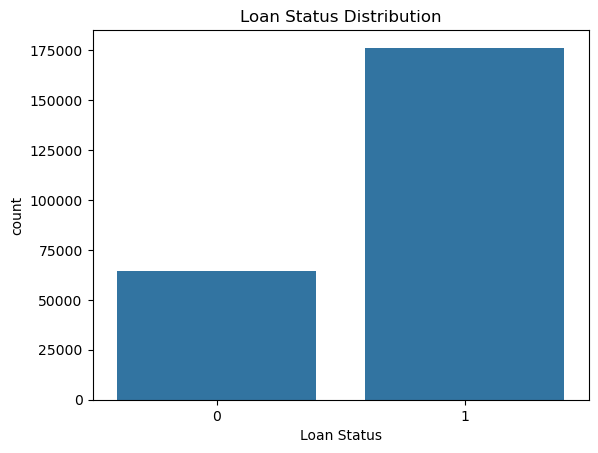

In [78]:
sns.countplot(x="Loan Status", data=df)

plt.title("Loan Status Distribution")

plt.show()

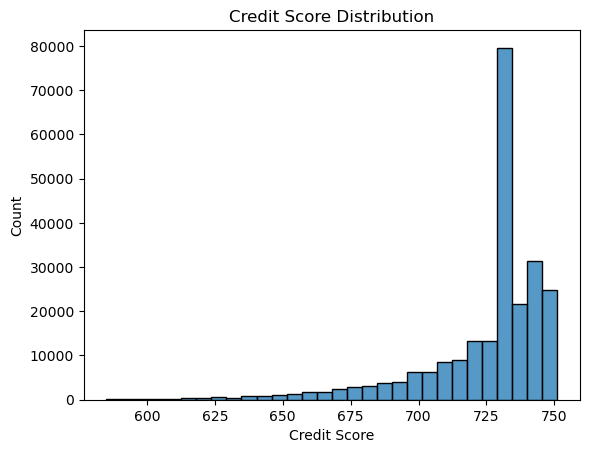

In [79]:
sns.histplot(df["Credit Score"], bins=30)

plt.title("Credit Score Distribution")

plt.show()

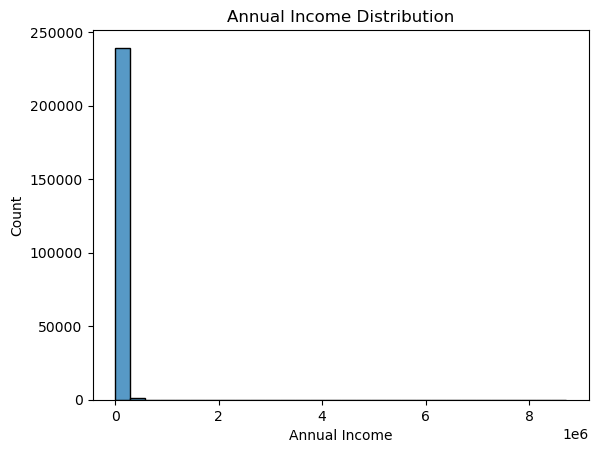

In [80]:
sns.histplot(df["Annual Income"], bins=30)

plt.title("Annual Income Distribution")

plt.show()

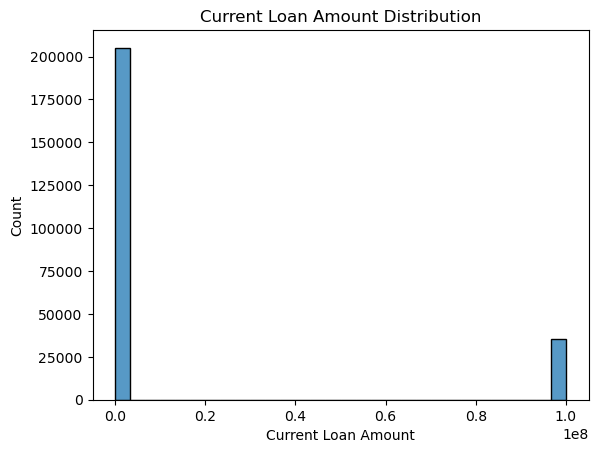

In [81]:
sns.histplot(df["Current Loan Amount"], bins=30)

plt.title("Current Loan Amount Distribution")

plt.show()

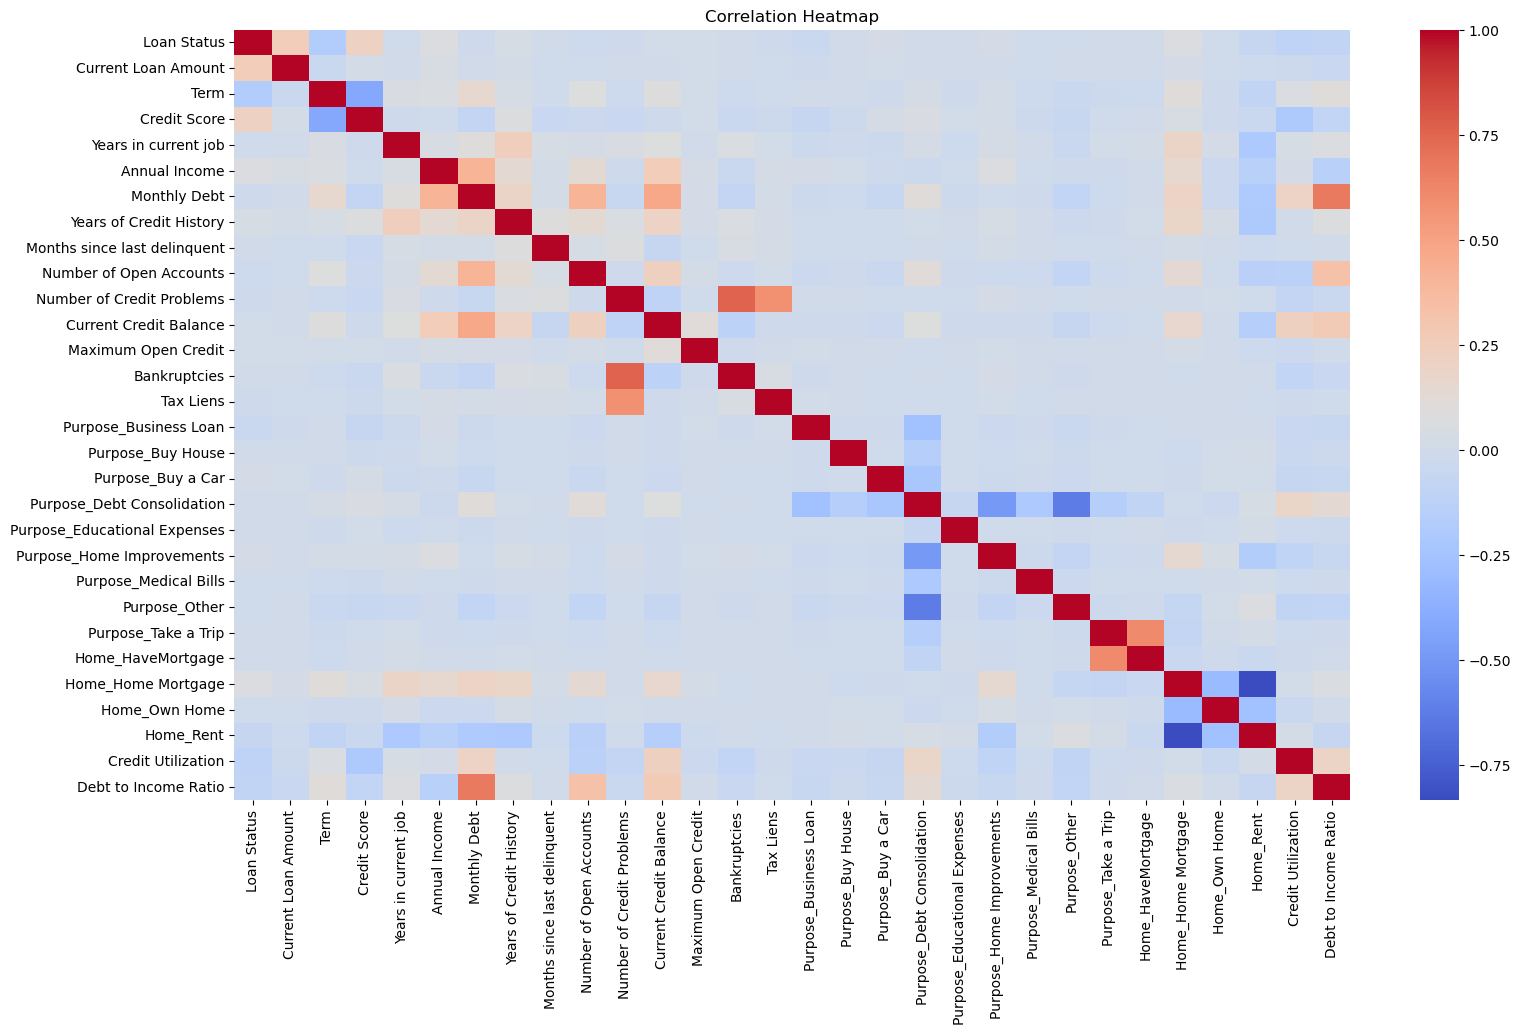

In [82]:
plt.figure(figsize=(18,10))

sns.heatmap(df.corr(),cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

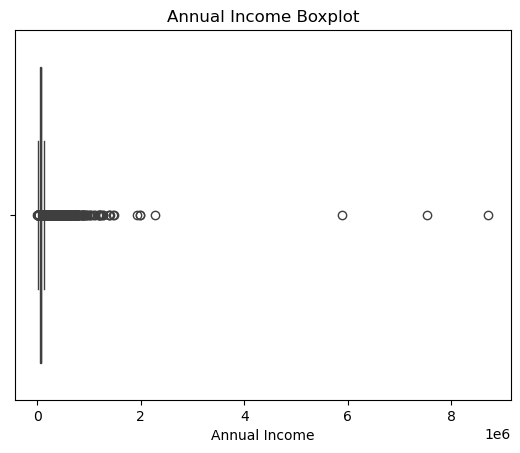

In [83]:
sns.boxplot(x=df["Annual Income"])

plt.title("Annual Income Boxplot")

plt.show()

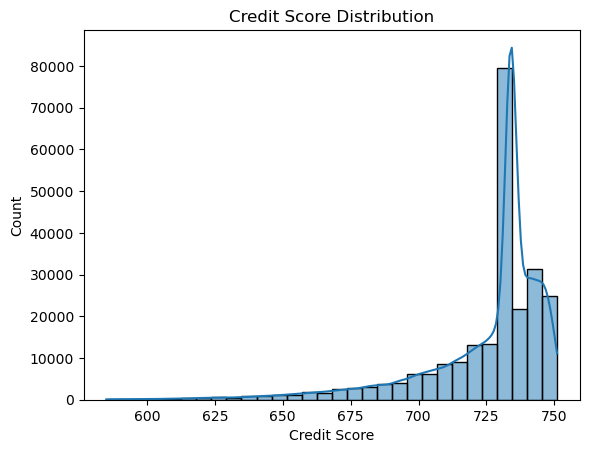

In [84]:
sns.histplot(df["Credit Score"],bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.show()

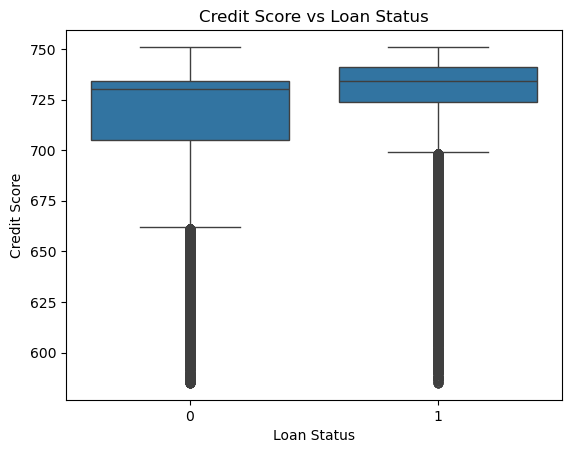

In [85]:
sns.boxplot(x="Loan Status",y="Credit Score",data=df)
plt.title("Credit Score vs Loan Status")
plt.show()

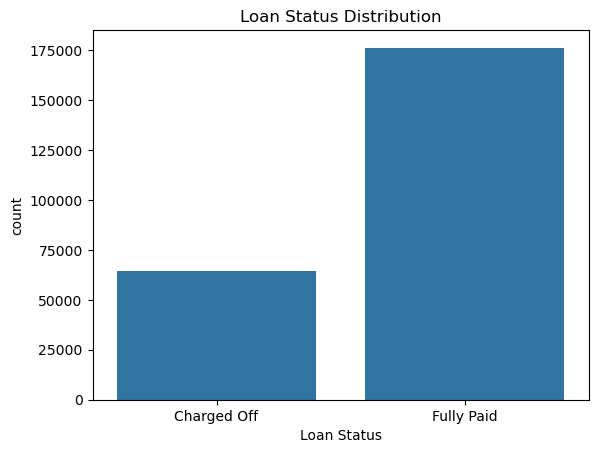

In [86]:
sns.countplot(x="Loan Status",data=df)
plt.title("Loan Status Distribution")
plt.xticks([0,1],["Charged Off", "Fully Paid"])
plt.show()

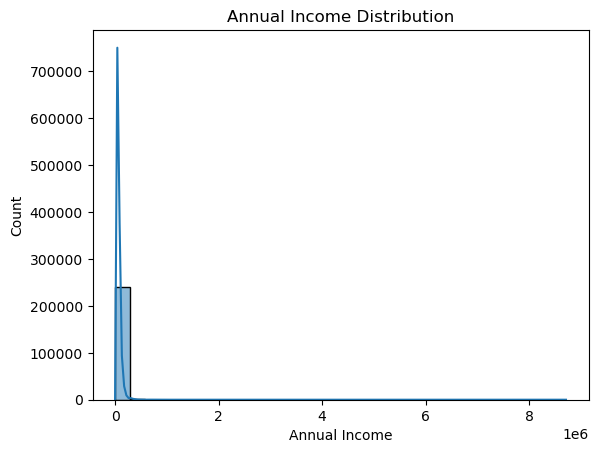

In [120]:
sns.histplot(
    df["Annual Income"],
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income")

plt.show()

In [92]:
y = df["Loan Status"]

In [90]:
X = df.drop("Loan Status", axis=1)

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42)

In [94]:
X_train.shape, X_test.shape

((192299, 29), (48075, 29))

In [95]:
np.isinf(df).sum()

Loan Status                       0
Current Loan Amount               0
Term                              0
Credit Score                      0
Years in current job              0
Annual Income                     0
Monthly Debt                      0
Years of Credit History           0
Months since last delinquent      0
Number of Open Accounts           0
Number of Credit Problems         0
Current Credit Balance            0
Maximum Open Credit               0
Bankruptcies                      0
Tax Liens                         0
Purpose_Business Loan             0
Purpose_Buy House                 0
Purpose_Buy a Car                 0
Purpose_Debt Consolidation        0
Purpose_Educational Expenses      0
Purpose_Home Improvements         0
Purpose_Medical Bills             0
Purpose_Other                     0
Purpose_Take a Trip               0
Home_HaveMortgage                 0
Home_Home Mortgage                0
Home_Own Home                     0
Home_Rent                   

In [132]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [96]:
df["Credit Utilization"].fillna(
    df["Credit Utilization"].median(),
    inplace=True)

In [97]:
np.isinf(df).sum()

Loan Status                       0
Current Loan Amount               0
Term                              0
Credit Score                      0
Years in current job              0
Annual Income                     0
Monthly Debt                      0
Years of Credit History           0
Months since last delinquent      0
Number of Open Accounts           0
Number of Credit Problems         0
Current Credit Balance            0
Maximum Open Credit               0
Bankruptcies                      0
Tax Liens                         0
Purpose_Business Loan             0
Purpose_Buy House                 0
Purpose_Buy a Car                 0
Purpose_Debt Consolidation        0
Purpose_Educational Expenses      0
Purpose_Home Improvements         0
Purpose_Medical Bills             0
Purpose_Other                     0
Purpose_Take a Trip               0
Home_HaveMortgage                 0
Home_Home Mortgage                0
Home_Own Home                     0
Home_Rent                   

In [101]:
df.isnull().sum()

Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Years in current job            0
Annual Income                   0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
Purpose_Business Loan           0
Purpose_Buy House               0
Purpose_Buy a Car               0
Purpose_Debt Consolidation      0
Purpose_Educational Expenses    0
Purpose_Home Improvements       0
Purpose_Medical Bills           0
Purpose_Other                   0
Purpose_Take a Trip             0
Home_HaveMortgage               0
Home_Home Mortgage              0
Home_Own Home                   0
Home_Rent                       0
Credit Utilization              0
Debt to Income

In [103]:
# Infinity değerleri NaN yap
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Tüm numeric kolonlardaki NaN değerleri median ile doldur
df = df.fillna(df.median(numeric_only=True))

In [104]:
X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [105]:
# Infinity var mı?
np.isinf(df.select_dtypes(include=[np.number])).sum()

Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Years in current job            0
Annual Income                   0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
Credit Utilization              0
Debt to Income Ratio            0
dtype: int64

In [106]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [107]:
# X içinde NaN var mı kontrol
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

In [108]:
df["Debt to Income Ratio"].fillna(
    df["Debt to Income Ratio"].median(),
    inplace=True)

In [109]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [110]:
X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [111]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.7471450858034321


In [112]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.58      0.19      0.28     12788
           1       0.76      0.95      0.85     35287

    accuracy                           0.75     48075
   macro avg       0.67      0.57      0.57     48075
weighted avg       0.71      0.75      0.70     48075



In [114]:
cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[ 2416, 10372],
       [ 1784, 33503]])

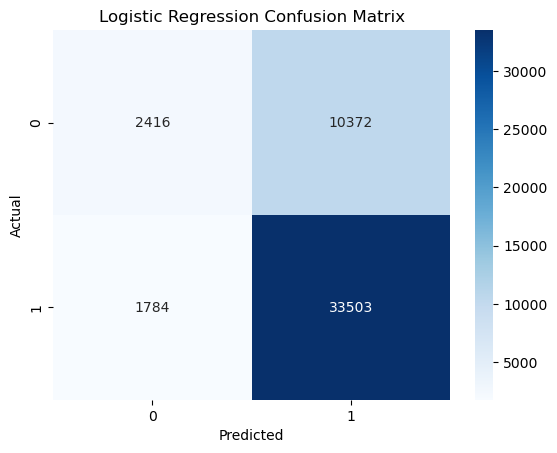

In [115]:
sns.heatmap(cm,annot=True,fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model: 33,503 iyi müşteriyi iyi tahmin etmiş. Gerçek riskli müşterilerden sadece 2416 sını yakalayabilmiş. 10,372 kötü müşteriyi iyi müşteri sanmış.1,784 iyi müşteriyi de kötü müşteri sanmış.

### Model; Düşük riskli müşterileri iyi ayırıyor,-Yüksek riskli müşterileri ayırmakta başarısız

### Decision Tree Classifier

In [116]:
from sklearn.tree import DecisionTreeClassifier

In [117]:
dt_model = DecisionTreeClassifier(
    random_state=42)

In [118]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [120]:
y_pred_dt = dt_model.predict(X_test)

In [121]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7164014560582423


In [122]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.47      0.53      0.50     12788
           1       0.82      0.79      0.80     35287

    accuracy                           0.72     48075
   macro avg       0.65      0.66      0.65     48075
weighted avg       0.73      0.72      0.72     48075



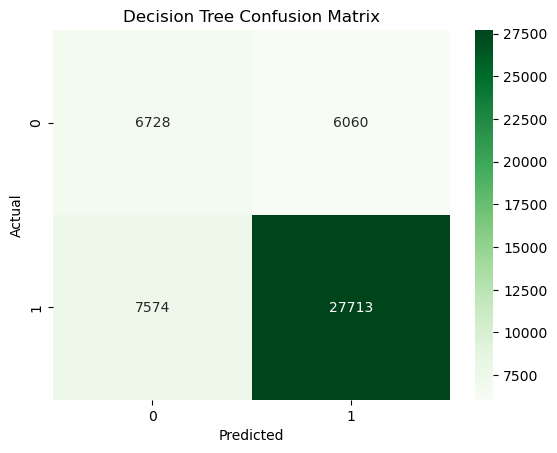

In [123]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Classifier

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

In [126]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
y_pred_rf = rf_model.predict(X_test)

In [128]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8013936557462299


In [129]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.41      0.52     12788
           1       0.81      0.94      0.87     35287

    accuracy                           0.80     48075
   macro avg       0.77      0.68      0.70     48075
weighted avg       0.79      0.80      0.78     48075



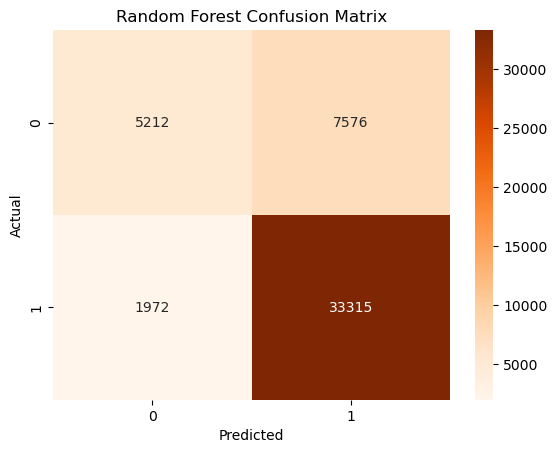

In [130]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Modelleri Karşılaştır

In [131]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [ accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)]})
results

,Model,Accuracy
0,Logistic Regression,0.747145
1,Decision Tree,0.716401
2,Random Forest,0.801394


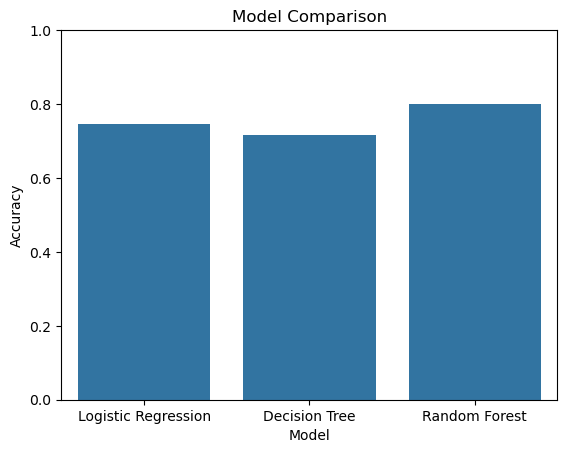

In [164]:
sns.barplot(x="Model",y="Accuracy", data=results)
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()

###  Classification Questions and Findings

## 1. Bir müşteri krediyi tamamen ödeyecek mi yoksa temerrüde mi düşecek?

Makine öğrenmesi modelleri müşterilerin kredi geri ödeme davranışlarını belirli bir doğruluk oranıyla tahmin edebilmiştir. Özellikle Random Forest modeli yaklaşık %80 doğruluk oranı ile en başarılı sonuçları üretmiştir.

---

## 2. Müşteri düşük riskli mi yoksa yüksek riskli bir borçlu mu?

Confusion matrix sonuçları, modellerin düşük riskli müşterileri daha başarılı şekilde belirlediğini göstermektedir. Ancak bazı yüksek riskli müşteriler yanlış şekilde düşük riskli olarak sınıflandırılmıştır.

---

## 3. Müşterinin finansal geçmişi kredi geri ödeme davranışını tahmin edebilir mi?

Evet. Credit Score, geçmiş kredi problemleri, iflas bilgileri ve kredi geçmişi gibi değişkenler modelin tahmin performansına katkı sağlamıştır.

---

## 4. Kredi kullanım oranı (Credit Utilization) kredi temerrüdünü etkiliyor mu?

Feature engineering ile oluşturulan Credit Utilization değişkeni, müşterinin mevcut kredi kullanım seviyesini göstermektedir. Yüksek kredi kullanım oranlarının riskli müşteri davranışıyla ilişkili olabileceği gözlemlenmiştir.

---

## 5. Aylık borcu yüksek olan müşterilerin temerrüde düşme olasılığı daha mı yüksektir?

EDA analizleri ve model sonuçları, yüksek Monthly Debt değerine sahip müşterilerin kredi riskinin artabileceğini göstermektedir.

---

## 6. İşte çalışma süresi kredi geri ödeme başarısını etkiliyor mu?

Years in current job değişkeni modele dahil edilmiştir. Daha uzun süreli iş geçmişine sahip müşterilerin daha istikrarlı ödeme davranışı gösterebileceği değerlendirilmiştir.

---

## 7. Ev sahipliği durumu kredi ödeme davranışını etkiliyor mu?

Home Ownership değişkeni modele dahil edilmiş ve ev sahipliği durumunun müşteri risk profiline katkı sağlayabileceği gözlemlenmiştir.

---

## 8. Daha önce kredi problemi yaşamış müşterilerin temerrüde düşme ihtimali daha mı yüksektir?

Number of Credit Problems ve Bankruptcies gibi değişkenler risk tahmininde önemli finansal göstergeler olarak değerlendirilmiştir.

---

## 9. İflas geçmişi riskli müşteri davranışını tahmin etmede kullanılabilir mi?

Evet. Bankruptcies değişkeni müşterinin finansal geçmişine dair önemli bir risk göstergesi olarak modele dahil edilmiştir.

---

## 10. Kredi temerrüdünü tahmin etmede en güçlü finansal göstergeler hangileridir?

Model sonuçlarına göre aşağıdaki değişkenler kredi riskini tahmin etmede önemli rol oynamaktadır:

- Credit Score
- Monthly Debt
- Annual Income
- Credit Utilization
- Debt to Income Ratio
- Number of Credit Problems
- Bankruptcies

### Bu sınıflandırma soruları doğrudan tek bir kesin cevap üretmek yerine, makine öğrenmesi modellerinin müşteri davranışlarını tahmin etme kapasitesini değerlendirmek amacıyla oluşturulmuştur.

Model performansları, feature ilişkileri, confusion matrix ve classification metrics kullanılarak hangi finansal değişkenlerin kredi geri ödeme davranışı üzerinde etkili olduğu analiz edilmiştir.